# Example wokflow

## Initial steps

### Load dependencies

In [1]:
from functionality.agent import *
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END

In [2]:
from IPython.display import Image, display

### Prepare the agent and intial state

In [3]:
agent = ChatOllama(base_url=f"http://localhost:11435", model="cogito:14b", num_ctx=8192*4)

In [ ]:
file_path = "/path/to/document.md"
state = read_markdown_file(file_path)
agent_state = AgentState(
    agent=agent,
    markdown=state,
    messages=[],
    message_history=[],
    iteration=0,
)

## Building the graph

### Full graph

In [5]:
builder = StateGraph(AgentState)

In [6]:
builder.add_node("update_message_history", update_message_history)
builder.add_node("up_iterator", next_iterator_step)
builder.add_node("stage_router", stage_router)

builder.add_node("node_extraction_loop", agent_euristic_extract_nodes)
builder.add_node("check_nodes_extraction_validity", check_nodes_extraction_validity)
builder.add_node("parse_nodes_extraction_result", parse_nodes_from_response)
builder.add_node("find_information_about_nodes", agent_search_information_about_existing_nodes)

builder.add_node("merge_descriptions_extracted_nodes", euristic_agent_merge_descriptions_extracted_nodes)
builder.add_node("compare_extracted_nodes", compare_nodes)
builder.add_node("update_extracted_nodes", update_extracted_nodes)


builder.add_node("update_extracted_nodes_loop", euristic_agent_update_extracted_nodes)

builder.add_node("update_kg_nodes", agent_update_knowledge_graph_nodes)
builder.add_node("find_existing_relationships", euristic_agent_find_relationships_for_nodes)
builder.add_node("relationship_loop", euristic_agent_extract_relationships)
builder.add_node("check_relationship_extraction_validity", check_relationship_extraction_validity)
builder.add_node("parse_relationships_extraction_result", parse_relationship_extraction_result)

builder.add_node("update_kg_relationships", agent_update_knowledge_graph_relationships)

In [7]:
builder.add_edge(START, "node_extraction_loop")

builder.add_conditional_edges(
    "stage_router",
    return_current_stage,
    {
        "node_extraction_loop": "node_extraction_loop",
        "update_extracted_nodes_loop":"update_extracted_nodes_loop",
        "relationship_loop":"relationship_loop",
        "merge_descriptions_extracted_nodes":"merge_descriptions_extracted_nodes",
        "compare_extracted_nodes":"compare_extracted_nodes",
    }
)
builder.add_conditional_edges(
    "node_extraction_loop",
    determine_action_nodes_extraction,
    {
        "parse": "parse_nodes_extraction_result",
        "retry": "stage_router"
    }
)

builder.add_edge("parse_nodes_extraction_result", "check_nodes_extraction_validity")

builder.add_conditional_edges(
    "check_nodes_extraction_validity",
    check_verification_status,
    {
        "valid": "find_information_about_nodes",
        "error": "node_extraction_loop"
    }
)

builder.add_edge("find_information_about_nodes", "update_extracted_nodes_loop")
builder.add_edge("update_kg_nodes", "find_existing_relationships")
builder.add_edge("find_existing_relationships", "relationship_loop")

builder.add_conditional_edges(
    "update_extracted_nodes_loop",
    select_action_for_update_extracted_nodes,
    {
        "done": "update_kg_nodes",
        "merge":"merge_descriptions_extracted_nodes",
        "compare": "compare_extracted_nodes"
    }
)
builder.add_conditional_edges(
    "merge_descriptions_extracted_nodes",
    check_step_validity,
    {
        "valid":"update_extracted_nodes",
        "error":"stage_router"
    }
)
builder.add_conditional_edges(
    "compare_extracted_nodes",
    check_step_validity,
    {
        "valid": "update_extracted_nodes",
        "error":"stage_router"
    }
)

builder.add_edge("update_extracted_nodes", "up_iterator")
builder.add_edge("up_iterator", "update_message_history")
builder.add_edge("update_message_history", "stage_router")

builder.add_conditional_edges(
    "relationship_loop",
    determine_action_nodes_extraction,
    {
        "parse": "parse_relationships_extraction_result",
        "retry":"stage_router"
    }
)

builder.add_edge("parse_relationships_extraction_result", "check_relationship_extraction_validity")

builder.add_conditional_edges(
    "check_relationship_extraction_validity",
    check_verification_status,
    {
        "valid": "update_kg_relationships",
        "error": "relationship_loop"
    }
)


In [8]:
euristic_node_extraction_graph = builder.compile()

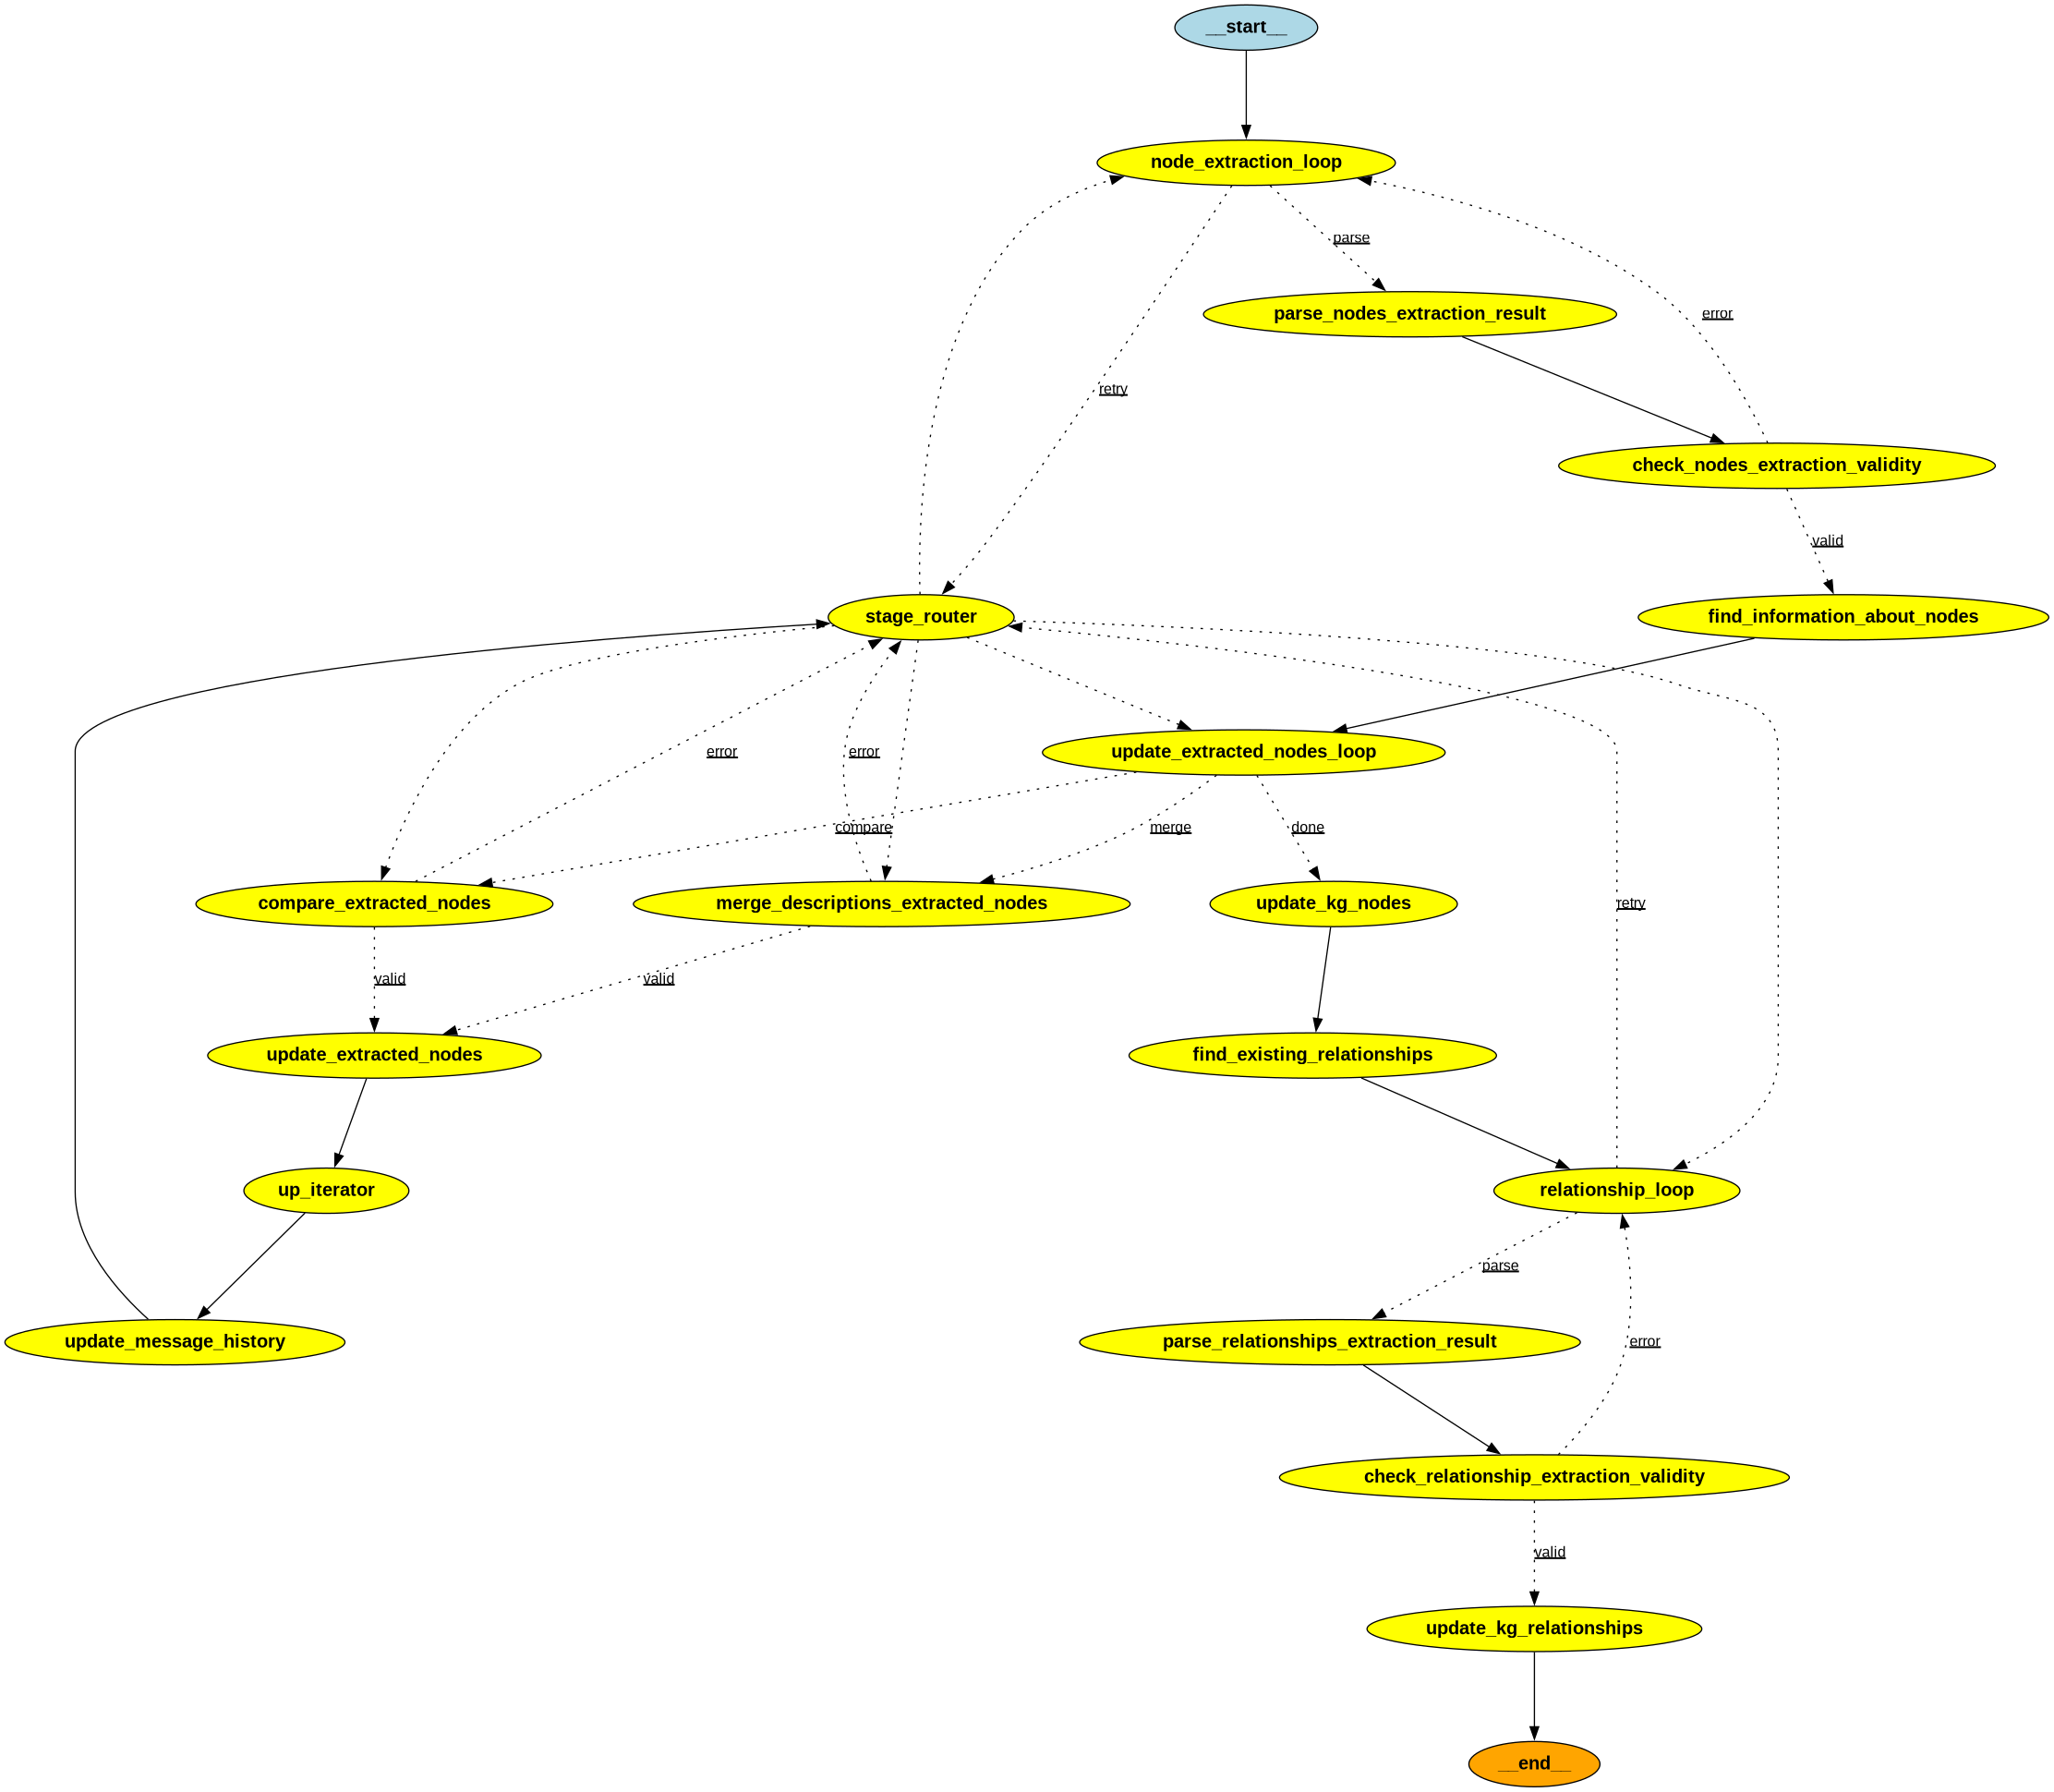

In [9]:
display(Image(euristic_node_extraction_graph.get_graph().draw_png()))

### Step-by-step subgraphs

In [5]:
builder = StateGraph(AgentState)

builder.add_node("node_extraction_loop", agent_euristic_extract_nodes)
builder.add_node("parse_nodes_from_response", parse_nodes_from_response)
builder.add_node("check_nodes_extraction_validity", check_nodes_extraction_validity)
builder.add_node("stage_router", stage_router)

builder.add_edge(START, "node_extraction_loop")
builder.add_conditional_edges(
    "node_extraction_loop",
    determine_action_nodes_extraction,
    #tools_condition,
    {
        "parse": "parse_nodes_from_response",
        "retry": "node_extraction_loop"
    }
)
builder.add_edge("parse_nodes_from_response", "check_nodes_extraction_validity")
builder.add_conditional_edges(
    "check_nodes_extraction_validity",
    check_verification_status,
    #tools_condition,
    {
        "valid": END,
        "error":"node_extraction_loop"
    }
)
extraction_block = builder.compile()

In [6]:
builder = StateGraph(AgentState)
builder.add_node("find_information_about_nodes", agent_search_information_about_existing_nodes)
builder.add_edge(START, "find_information_about_nodes")
builder.add_edge("find_information_about_nodes", END)
searching_info_block = builder.compile()

In [7]:
builder = StateGraph(AgentState)
builder.add_node("update_extracted_nodes_loop", euristic_agent_update_extracted_nodes)
builder.add_node("merge_descriptions_extracted_nodes", euristic_agent_merge_descriptions_extracted_nodes)
builder.add_node("compare_extracted_nodes", compare_nodes)
builder.add_node("check_step_validity", check_step_validity)
builder.add_node("update_extracted_nodes", update_extracted_nodes)
builder.add_node("update_message_history", update_message_history)
builder.add_node("up_iterator", next_iterator_step)

builder.add_edge(START, "update_extracted_nodes_loop")
builder.add_conditional_edges(
    "update_extracted_nodes_loop",
    select_action_for_update_extracted_nodes,
    {
        "done": END,
        "merge":"merge_descriptions_extracted_nodes",
        "compare": "compare_extracted_nodes"
    }
)
builder.add_edge("merge_descriptions_extracted_nodes", "check_step_validity")
builder.add_edge("compare_extracted_nodes", "check_step_validity")

builder.add_conditional_edges(
    "check_step_validity",
    check_verification_status,
    {
        "valid":"update_extracted_nodes",
        "error":"update_extracted_nodes_loop"
    }
)

builder.add_edge("update_extracted_nodes", "up_iterator")
builder.add_edge("up_iterator", "update_message_history")
builder.add_edge("update_message_history", "update_extracted_nodes_loop")

update_extracted_block = builder.compile()

In [8]:
builder = StateGraph(AgentState)
builder.add_node("find_existing_relationships", euristic_agent_find_relationships_for_nodes)
builder.add_edge(START, "find_existing_relationships")
builder.add_edge("find_existing_relationships", END)
finding_existing_relationships_block = builder.compile()

In [9]:
builder = StateGraph(AgentState)
builder.add_node("relationship_loop", euristic_agent_extract_relationships)
builder.add_node("check_relationship_extraction_validity", check_relationship_extraction_validity)
builder.add_node("parse_relationships_extraction_result", parse_relationship_extraction_result)

builder.add_edge(START, "relationship_loop")
builder.add_conditional_edges(
    "relationship_loop",
    determine_action_nodes_extraction,
    #tools_condition,
    {
        "parse": "parse_relationships_extraction_result",
        "retry":"relationship_loop"
    }
)
builder.add_edge("parse_relationships_extraction_result", "check_relationship_extraction_validity")
builder.add_conditional_edges(
    "check_relationship_extraction_validity",
    check_verification_status,
    #tools_condition,
    {
        "valid": END,
        "error":"relationship_loop"
    }
)
relationship_extraction_block = builder.compile()

In [10]:
builder = StateGraph(AgentState)
builder.add_node("update_kg_relationships", agent_update_knowledge_graph_relationships)
builder.add_edge(START, "update_kg_relationships")
builder.add_edge("update_kg_relationships", END)
updating_relationships_block = builder.compile()

## Running the graph

### Full graph

In [ ]:
finals_state = euristic_node_extraction_graph.run(agent_state, {"recursion_limit": 100})

### Step-by-step subgraphs

The default value of recursion_limit is 25, which is too low for the task.  

In [ ]:
after_extraction_state = await extraction_block.ainvoke(agent_state, {"recursion_limit": 50})

In [ ]:
after_searching_info_state = await searching_info_block.ainvoke(after_extraction_state)

Since the graph has intended loops, the recursion_limit must be adjusted based on the number of nodes in subgraph and desired number of iterations.

In [21]:
loop_length = 7 # amount of LangGraph nodes
repetitions = 5 # amount of times to repeat the loop 
loop_budget = len(after_searching_info_state["nodes"]) * loop_length * repetitions
loop_budget

315

In [ ]:
after_update_extracted_block = await update_extracted_block.ainvoke(after_searching_info_state, {"recursion_limit": loop_budget})

In [ ]:
after_update_extracted_block["nodes"]

In [ ]:
new_state = agent_update_knowledge_graph_nodes(after_update_extracted_block)

In [ ]:
after_finding_existing_relationships_block = await finding_existing_relationships_block.ainvoke(after_update_extracted_block)

In [29]:
after_finding_existing_relationships_block["existing_relationships"]

[]

In [ ]:
after_relationship_extraction_block = await relationship_extraction_block.ainvoke(after_finding_existing_relationships_block, {"recursion_limit": 50})

In [ ]:
after_relationship_extraction_block["relationships"]

In [ ]:
updating_relationships_block_state = await updating_relationships_block.ainvoke(after_relationship_extraction_block)